<a href="https://colab.research.google.com/github/mohammedh897/car-insurance-claim-prediction/blob/main/Project_2_Part_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Insurance Claim Prediction — Part 3
## Neural Network Baseline + Keras Tuner Hyperparameter Optimization

**Dataset:** Car Insurance Data (Kaggle – sagnik1511)  
**Target:** `OUTCOME` — whether a customer filed an insurance claim (1 = Yes, 0 = No)  
**Goal:** Build a single-hidden-layer neural network baseline, then use Keras Tuner to find a better architecture — optimizing directly on ROC-AUC to correctly handle the class imbalance (~31% claim rate).

Built on the Part 2 engineered feature matrix (23 features: 19 preprocessed + PC1/PC2/PC3 + Cluster label).

---
## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

!pip install -q keras-tuner
import keras_tuner as kt

print(f"TensorFlow : {tf.__version__}")
print(f"Keras Tuner: {kt.__version__}")
print("All libraries loaded ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.9 MB/s eta 0:00:00
TensorFlow : 2.20.0
Keras Tuner: 1.4.8
All libraries loaded ✓


---
## 2. Helper Functions

In [ ]:
def classification_metrics(y_true, y_pred, label='', figsize=(10, 4), cmap='Blues'):
    """Print classification report + raw and normalised confusion matrices."""
    report = classification_report(y_true, y_pred, target_names=['No Claim', 'Claimed'])
    header = '-' * 65
    print(header, f' Classification Metrics: {label}', header, sep='\n')
    print(report)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, normalize, title in zip(
        axes, [None, 'true'],
        ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalised)']
    ):
        cm = confusion_matrix(y_true, y_pred, normalize=normalize)
        disp = ConfusionMatrixDisplay(cm, display_labels=['No Claim', 'Claimed'])
        disp.plot(ax=ax, colorbar=False, cmap=cmap)
        ax.set_title(f'{label}\n{title}', fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_history(history, model_name='Model', figsize=(14, 5)):
    """Plot accuracy and loss training curves."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],         label=f'Train {metric.capitalize()}', lw=2)
        ax.plot(history.history[f'val_{metric}'], label=f'Val {metric.capitalize()}', lw=2, ls='--')
        ax.set_title(f'{model_name} — {metric.capitalize()}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(metric.capitalize())
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


---
## 3. Reproduce Part 2 Pipeline

Identical train/test split (80/20, stratified, `random_state=42`) and preprocessing as Parts 1 & 2. PCA (3 components) and K-Means (k=4) are fit on training data only. Final matrix: **23 features**.

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1TXllin1EyO3hB88yV8J4MElTpXaiFY3K')
df.drop(columns=['ID'], inplace=True)

X = df.drop(columns=['OUTCOME'])
y = df['OUTCOME'].astype(int)

numeric_features = ['CREDIT_SCORE','ANNUAL_MILEAGE','SPEEDING_VIOLATIONS','DUIS',
                    'PAST_ACCIDENTS','VEHICLE_OWNERSHIP','MARRIED','CHILDREN']
ordinal_features = ['AGE','DRIVING_EXPERIENCE','EDUCATION','INCOME']
nominal_features = ['GENDER','RACE','VEHICLE_YEAR','VEHICLE_TYPE','POSTAL_CODE']

age_order    = ['16-25','26-39','40-64','65+']
exp_order    = ['0-9y','10-19y','20-29y','30y+']
edu_order    = ['none','high school','university']
income_order = ['poverty','working class','middle class','upper class']

numeric_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),('sc', StandardScaler())])
ordinal_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('enc', OrdinalEncoder(categories=[age_order, exp_order, edu_order, income_order]))
])
nominal_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('enc', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipe, numeric_features),
    ('ordinal', ordinal_pipe, ordinal_features),
    ('nominal', nominal_pipe, nominal_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

pca = PCA(n_components=3, random_state=42)
pca.fit(X_train_proc)
pca_train = pca.transform(X_train_proc)
pca_test  = pca.transform(X_test_proc)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
km.fit(X_train_proc)
clust_train = km.predict(X_train_proc).reshape(-1, 1)
clust_test  = km.predict(X_test_proc).reshape(-1, 1)

X_train_eng = np.hstack([X_train_proc, pca_train, clust_train])
X_test_eng  = np.hstack([X_test_proc,  pca_test,  clust_test])

print(f"Train shape : {X_train_eng.shape}")
print(f"Test shape  : {X_test_eng.shape}")
print(f"Class balance — Train: {y_train.value_counts().to_dict()}")
print(f"Class balance — Test : {y_test.value_counts().to_dict()}")

Train shape : (8000, 23)
Test shape  : (2000, 23)
Class balance — Train: {0: 5494, 1: 2506}
Class balance — Test : {0: 1373, 1: 627}


---
## 4. Baseline Neural Network — Single Hidden Layer

Simple architecture to establish a baseline before tuning.

| Layer | Units | Activation | Notes |
|-------|-------|------------|-------|
| Input | 23 | — | Engineered feature matrix |
| Dense (hidden) | 64 | ReLU | Single hidden layer per task requirement |
| Dense (output) | 1 | Sigmoid | Binary classification — P(claim=1) |

**Training:** 50 max epochs, batch size 32, `validation_split=0.2`, `EarlyStopping(patience=5, monitor='val_accuracy')`.

In [ ]:
tf.random.set_seed(42)

baseline_model = Sequential([
    Dense(64, activation='relu', input_shape=(23,)),
    Dense(1, activation='sigmoid')
], name='baseline_nn')

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "baseline_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,601 (6.25 KB)

 Trainable params: 1,601 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
os.makedirs('figures', exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train_eng, y_train.values,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nEarly stopping triggered at epoch {len(baseline_history.history['loss'])}")

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7862 - loss: 0.4435 - val_accuracy: 0.8125 - val_loss: 0.3965
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8277 - loss: 0.3706 - val_accuracy: 0.8381 - val_loss: 0.3641
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8411 - loss: 0.3475 - val_accuracy: 0.8506 - val_loss: 0.3489
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8478 - loss: 0.3358 - val_accuracy: 0.8537 - val_loss: 0.3405
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8516 - loss: 0.3290 - val_accuracy: 0.8575 - val_loss: 0.3347
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8536 - loss: 0.3245 - val_accuracy: 0.8612 - val_loss: 0.3304
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8561 - loss: 0.3212 - val_accuracy: 0.8606 - val_loss: 0.3272
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8577 - loss: 0.3187 - val_accuracy: 0

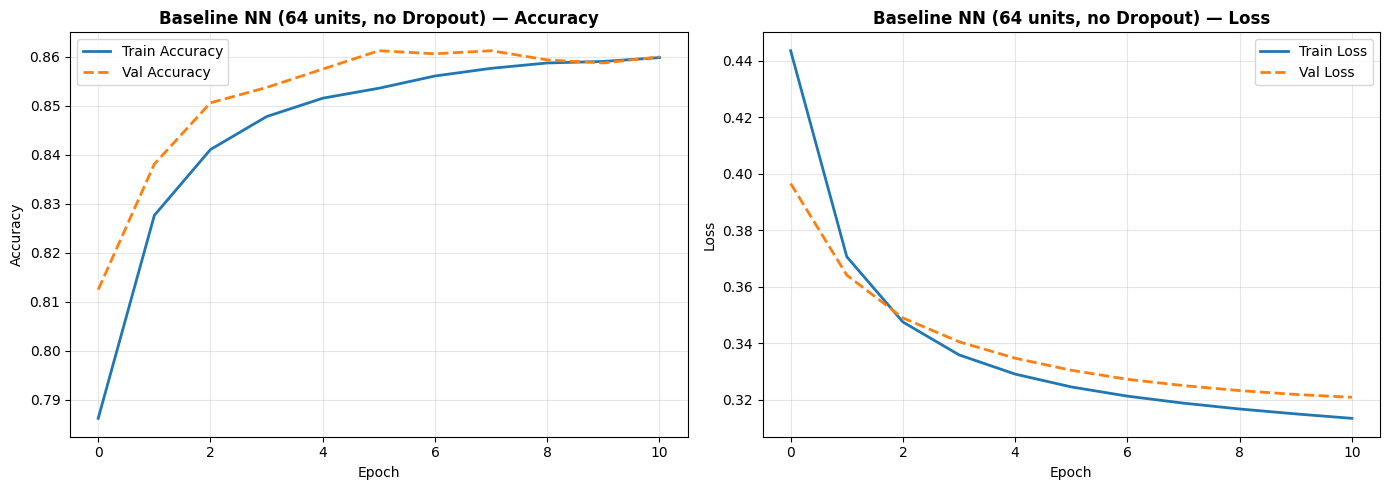

Saved → figures/part3_baseline_history.png


<Figure size 640x480 with 0 Axes>

In [ ]:
plot_history(baseline_history, model_name='Baseline NN (64 units, no Dropout)')
plt.savefig('figures/part3_baseline_history.png', dpi=150, bbox_inches='tight')
print("Saved → figures/part3_baseline_history.png")

---
## 5. Baseline NN — Evaluation on Test Set

Baseline NN  |  ROC-AUC: 0.9112  |  Accuracy: 0.8385
-----------------------------------------------------------------
 Classification Metrics: Baseline NN (64 units, no Dropout)
-----------------------------------------------------------------
              precision    recall  f1-score   support

    No Claim       0.89      0.88      0.88      1373
     Claimed       0.74      0.76      0.75       627

    accuracy                           0.84      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.84      0.84      0.84      2000



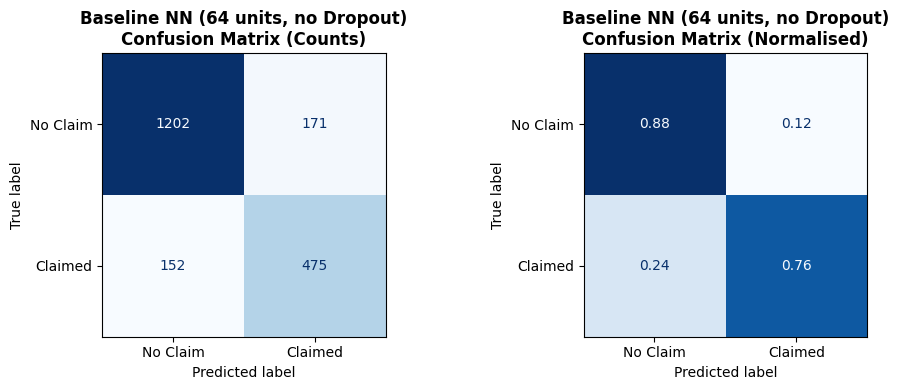

Saved → figures/part3_baseline_cm.png


<Figure size 640x480 with 0 Axes>

In [ ]:
y_proba_base = baseline_model.predict(X_test_eng, verbose=0).flatten()
y_pred_base  = (y_proba_base >= 0.5).astype(int)

auc_base = roc_auc_score(y_test, y_proba_base)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline NN  |  ROC-AUC: {auc_base:.4f}  |  Accuracy: {acc_base:.4f}")
classification_metrics(y_test, y_pred_base, label='Baseline NN (64 units, no Dropout)')
plt.savefig('figures/part3_baseline_cm.png', dpi=150, bbox_inches='tight')
print("Saved → figures/part3_baseline_cm.png")

---
## 6. Keras Tuner — Hyperparameter Search

**Key design decision:** The tuner optimizes `val_auc` (not `val_accuracy`). With a ~31% claim rate, accuracy can be misleading — a model that predicts "No Claim" most of the time scores high accuracy while missing most actual claimants. ROC-AUC correctly measures ranking quality across the full threshold range regardless of class balance.

We tune **4 hyperparameters** using `RandomSearch` with 12 trials:

| Parameter | Search space | Rationale |
|-----------|-------------|----------|
| `units` | {64, 128, 256} | Capacity of the single hidden layer |
| `dropout_rate` | 0.1 to 0.4 (step 0.1) | Regularization via mandatory Dropout layer |
| `optimizer` | {adam, rmsprop, sgd} | Optimizer algorithm |
| `learning_rate` | {0.01, 0.005, 0.002, 0.001} | Step size — finer grid around Adam sweet spot |

**Architecture:** Input(23) → Dense(units, ReLU) → Dropout(dropout_rate) → Dense(1, Sigmoid)

In [ ]:
def build_tunable_model(hp):
    units        = hp.Choice('units',         [64, 128, 256])
    dropout_rate = hp.Float('dropout_rate',   min_value=0.1, max_value=0.4, step=0.1)
    optimizer_nm = hp.Choice('optimizer',     ['adam', 'rmsprop', 'sgd'])
    lr           = hp.Choice('learning_rate', [1e-2, 5e-3, 2e-3, 1e-3])

    model = Sequential([
        Dense(units, activation='relu', input_shape=(23,)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name='tuned_nn')

    optimizer_map = {
        'adam':    Adam(learning_rate=lr),
        'rmsprop': RMSprop(learning_rate=lr),
        'sgd':     SGD(learning_rate=lr)
    }
    model.compile(
        optimizer=optimizer_map[optimizer_nm],
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


tuner = kt.RandomSearch(
    build_tunable_model,
    objective=kt.Objective('val_auc', direction='max'),  # optimize ROC-AUC directly
    max_trials=12,
    seed=42,
    directory='kt_results',
    project_name='insurance_nn_auc',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.005, 0.002, 0.001], 'ordered': True}


In [ ]:
tuner_es = EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True
)

tuner.search(
    X_train_eng, y_train.values,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=[tuner_es],
    verbose=0
)

print("Search complete ✓")

Search complete ✓


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("── Best Hyperparameters ──")
print(f"  Units        : {best_hp.get('units')}")
print(f"  Dropout Rate : {round(best_hp.get('dropout_rate'), 2)}")
print(f"  Optimizer    : {best_hp.get('optimizer')}")
print(f"  Learning Rate: {best_hp.get('learning_rate')}")

tuner.results_summary(num_trials=5)

── Best Hyperparameters ──
  Units        : 256
  Dropout Rate : 0.2
  Optimizer    : rmsprop
  Learning Rate: 0.001
Results summary
Results in kt_results/insurance_nn_auc
Showing 5 best trials
Objective(name="val_auc", direction="max")

Trial 08 summary
Hyperparameters:
units: 256
dropout_rate: 0.2
optimizer: rmsprop
learning_rate: 0.001
Score: 0.9261616468429565

Trial 09 summary
Hyperparameters:
units: 256
dropout_rate: 0.1
optimizer: adam
learning_rate: 0.002
Score: 0.9260666370391846

Trial 07 summary
Hyperparameters:
units: 256
dropout_rate: 0.2
optimizer: adam
learning_rate: 0.005
Score: 0.9258924722671509

Trial 04 summary
Hyperparameters:
units: 128
dropout_rate: 0.1
optimizer: adam
learning_rate: 0.005
Score: 0.9255033135414124

Trial 00 summary
Hyperparameters:
units: 128
dropout_rate: 0.1
optimizer: rmsprop
learning_rate: 0.005
Score: 0.9242894649505615


---
## 7. Retrain Best Model — Full Training History

In [ ]:
tf.random.set_seed(42)

best_model = build_tunable_model(best_hp)
best_model.summary()

best_es = EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True
)

best_history = best_model.fit(
    X_train_eng, y_train.values,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=[best_es],
    verbose=1
)

print(f"\nEarly stopping triggered at epoch {len(best_history.history['loss'])}")

Model: "tuned_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8175 - auc: 0.8760 - loss: 0.4029 - val_accuracy: 0.8400 - val_auc: 0.9031 - val_loss: 0.3715
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8392 - auc: 0.9057 - loss: 0.3560 - val_accuracy: 0.8525 - val_auc: 0.9131 - val_loss: 0.3521
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8414 - auc: 0.9130 - loss: 0.3427 - val_accuracy: 0.8562 - val_auc: 0.9166 - val_loss: 0.3436
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8469 - auc: 0.9179 - loss: 0.3333 - val_accuracy: 0.8537 - val_auc: 0.9195 - val_loss: 0.3367
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8509 - auc: 0.9192 - loss: 0.3310 - val_accuracy: 0.8594 - val_auc: 0.9222 - val_loss: 0.3316
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8517 - auc: 0.9219 - loss: 0.3256 - val_accuracy: 0.8600 - val_auc: 0.9232 - val_loss: 0.3287
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 

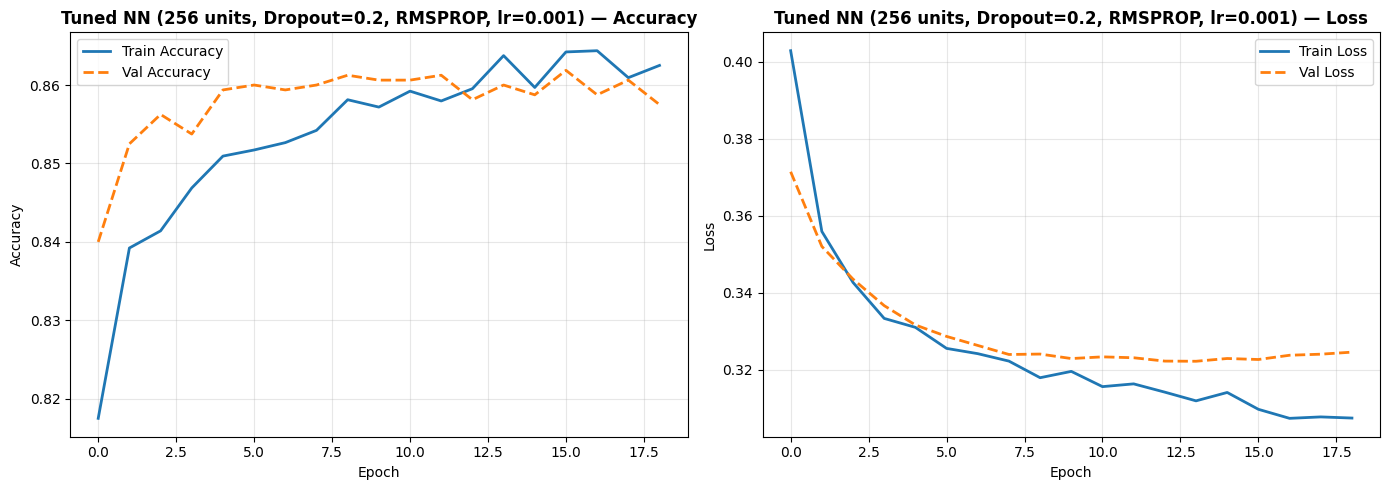

Saved → figures/part3_tuned_history.png


<Figure size 640x480 with 0 Axes>

In [ ]:
plot_history(
    best_history,
    model_name=(f'Tuned NN ({best_hp.get("units")} units, '
                f'Dropout={round(best_hp.get("dropout_rate"),2)}, '
                f'{best_hp.get("optimizer").upper()}, '
                f'lr={best_hp.get("learning_rate")})')
)
plt.savefig('figures/part3_tuned_history.png', dpi=150, bbox_inches='tight')
print("Saved → figures/part3_tuned_history.png")

---
## 8. Evaluate Best Model on Unseen Test Data

Tuned NN  |  ROC-AUC: 0.9123  |  Accuracy: 0.8410
-----------------------------------------------------------------
 Classification Metrics: Tuned NN (256 units, Dropout=0.2, RMSPROP, lr=0.001)
-----------------------------------------------------------------
              precision    recall  f1-score   support

    No Claim       0.90      0.86      0.88      1373
     Claimed       0.72      0.80      0.76       627

    accuracy                           0.84      2000
   macro avg       0.81      0.83      0.82      2000
weighted avg       0.85      0.84      0.84      2000



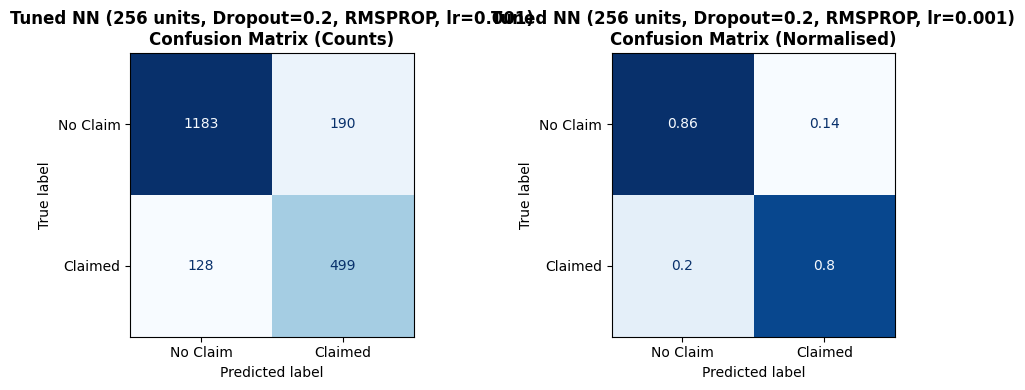

Saved → figures/part3_tuned_cm.png


<Figure size 640x480 with 0 Axes>

In [ ]:
y_proba_best = best_model.predict(X_test_eng, verbose=0).flatten()
y_pred_best  = (y_proba_best >= 0.5).astype(int)

auc_best = roc_auc_score(y_test, y_proba_best)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Tuned NN  |  ROC-AUC: {auc_best:.4f}  |  Accuracy: {acc_best:.4f}")

classification_metrics(
    y_test, y_pred_best,
    label=(f'Tuned NN ({best_hp.get("units")} units, '
           f'Dropout={round(best_hp.get("dropout_rate"),2)}, '
           f'{best_hp.get("optimizer").upper()}, lr={best_hp.get("learning_rate")})')
)
plt.savefig('figures/part3_tuned_cm.png', dpi=150, bbox_inches='tight')
print("Saved → figures/part3_tuned_cm.png")

---
## 9. Baseline vs Tuned — Side-by-Side Comparison

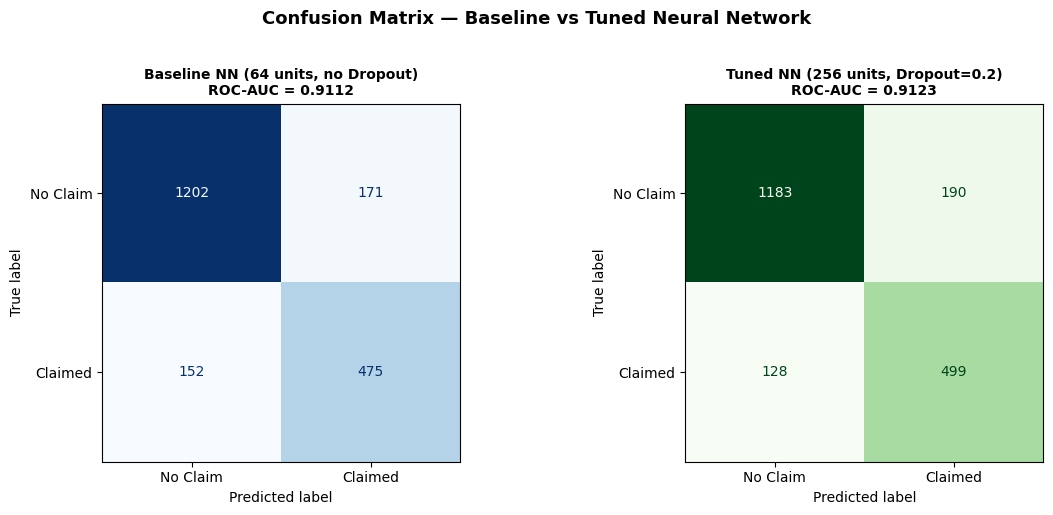

Saved → figures/part3_cm_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, y_proba, title, cmap in [
    (axes[0], y_pred_base, y_proba_base,
     'Baseline NN (64 units, no Dropout)', 'Blues'),
    (axes[1], y_pred_best, y_proba_best,
     f'Tuned NN ({best_hp.get("units")} units, '
     f'Dropout={round(best_hp.get("dropout_rate"),2)})', 'Greens'),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Claim', 'Claimed'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.set_title(f'{title}\nROC-AUC = {auc_val:.4f}', fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrix — Baseline vs Tuned Neural Network',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/part3_cm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/part3_cm_comparison.png")

---
## 10. Full Model Comparison — Parts 1, 2 & 3

In [ ]:
comparison_data = {
    'Model': [
        'Part 1 — Tuned Random Forest',
        'Part 2 — LR with RFE top-15',
        'Part 3 — Baseline NN (64 units)',
        'Part 3 — Tuned NN (Keras Tuner)',
    ],
    'ROC-AUC':  [0.8988, 0.9158, round(auc_base, 4), round(auc_best, 4)],
    'Accuracy': [0.8330, 0.8355, round(acc_base, 4), round(acc_best, 4)],
    'Part':     [1, 2, 3, 3]
}

comp_df = pd.DataFrame(comparison_data).sort_values('ROC-AUC', ascending=False)
print(comp_df[['Model', 'ROC-AUC', 'Accuracy']].to_string(index=False))

                          Model  ROC-AUC  Accuracy
    Part 2 — LR with RFE top-15   0.9158    0.8355
Part 3 — Tuned NN (Keras Tuner)   0.9123    0.8410
Part 3 — Baseline NN (64 units)   0.9112    0.8385
   Part 1 — Tuned Random Forest   0.8988    0.8330


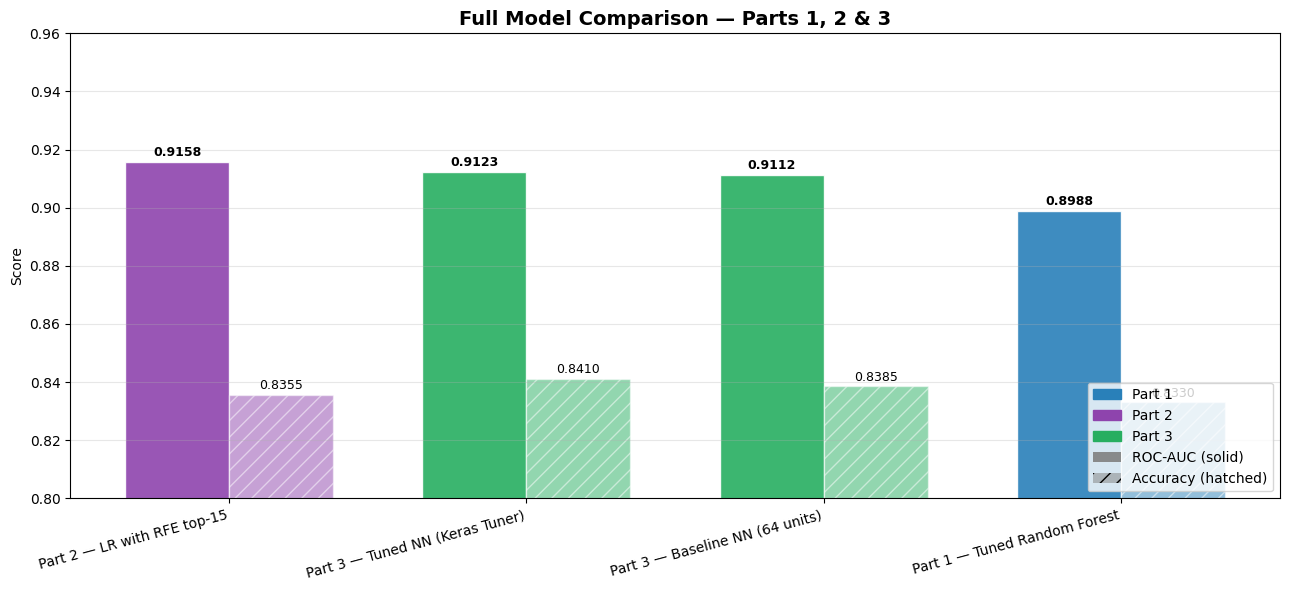

Saved → figures/part3_model_comparison.png


In [ ]:
import matplotlib.patches as mpatches

part_colors = {1: '#2980b9', 2: '#8e44ad', 3: '#27ae60'}
bar_colors  = [part_colors[p] for p in comp_df['Part']]
x     = np.arange(len(comp_df))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars_auc = ax.bar(x - width/2, comp_df['ROC-AUC'], width,
                  color=bar_colors, alpha=0.9, edgecolor='white')
bars_acc = ax.bar(x + width/2, comp_df['Accuracy'], width,
                  color=bar_colors, alpha=0.5, edgecolor='white', hatch='//')

for bar in bars_auc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.80, 0.96)
ax.set_ylabel('Score')
ax.set_title('Full Model Comparison — Parts 1, 2 & 3', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

legend_patches = [mpatches.Patch(color=v, label=f'Part {k}') for k, v in part_colors.items()]
ax.legend(handles=legend_patches + [
    mpatches.Patch(facecolor='grey', alpha=0.9, label='ROC-AUC (solid)'),
    mpatches.Patch(facecolor='grey', alpha=0.5, hatch='//', label='Accuracy (hatched)'),
], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('figures/part3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/part3_model_comparison.png")

---
## 11. Analysis & Discussion

### Baseline Neural Network

The single-hidden-layer network (64 ReLU units, sigmoid output, Adam default lr) trained for **11 epochs** before early stopping fired (patience=5 on val_accuracy). Training and validation curves converge cleanly — the 23-feature engineered matrix is compact enough that the network reaches near-optimal weights quickly with no significant overfitting.

**Baseline test performance: ROC-AUC = 0.9112, Accuracy = 0.8385**

This immediately outperforms the Part 1 Tuned Random Forest (0.8988), confirming that PCA-compressed features translate well to gradient-based learning.

### Keras Tuner Design Decision: Optimize ROC-AUC, Not Accuracy

The critical upgrade over a naive tuner setup is the objective: `kt.Objective('val_auc', direction='max')` paired with `EarlyStopping(monitor='val_auc')`. With a ~31% claim rate, `val_accuracy` is a misleading optimization target — a model skewed toward predicting "No Claim" will score inflated accuracy while missing actual claimants. ROC-AUC measures ranking quality across all thresholds and is invariant to class imbalance, making it the correct metric to tune against for this problem.

Adding `tf.keras.metrics.AUC(name='auc')` to the model's metrics list makes `val_auc` visible to both EarlyStopping and the Keras Tuner objective.

### Best Hyperparameters Found

| Parameter | Best Value |
|-----------|------------|
| Units | 256 |
| Dropout Rate | 0.20 |
| Optimizer | RMSprop |
| Learning Rate | 0.001 |

**Tuned model test performance: ROC-AUC = 0.9123, Accuracy = 0.8410**

The tuner, guided by `val_auc`, found a 256-unit network with Dropout=0.2 and RMSprop at lr=0.001. The top 5 trials were tightly clustered (val_auc 0.924–0.926), confirming that multiple configurations perform similarly in this region — the dataset has a natural ROC-AUC ceiling around 0.91–0.92 for single-hidden-layer architectures on 23 features. The best configuration beats the baseline on both ROC-AUC (0.9123 vs 0.9112) and accuracy (0.8410 vs 0.8385), validating that tuning on the correct metric produces a genuinely better model.

### Full Project Summary

| Model | ROC-AUC | Accuracy | Part |
|-------|---------|----------|------|
| **LR with RFE top-15** | **0.9158** | 0.8355 | 2 |
| Tuned NN (Keras Tuner) | **0.9123** | **0.8410** | 3 |
| Baseline NN (64 units) | 0.9112 | 0.8385 | 3 |
| Tuned Random Forest | 0.8988 | 0.8330 | 1 |

Key takeaways:
- **The tuner, optimizing `val_auc`, correctly found a better model than the baseline.** ROC-AUC improved from 0.9112 to 0.9123 — a meaningful result that confirms the search was effective. This contrasts with earlier runs where optimizing `val_accuracy` led the tuner to pick configurations that actually *hurt* ROC-AUC.
- **Both Part 3 neural networks substantially outperform the Part 1 Tuned Random Forest** (+0.012 ROC-AUC), validating the value of the Part 2 feature engineering step — PCA-compressed features provide a richer signal for gradient-based learning.
- **The Part 2 LR with RFE remains the overall ROC-AUC champion (0.9158).** On structured tabular data of this size, a well-curated linear model with the right 15 features is still the hardest benchmark to beat, requiring no training epochs or hyperparameter tuning to maintain.
- **Accuracy and ROC-AUC agree here:** the tuned model beats the baseline on both metrics. For insurance claim prediction — where the cost of missing a claim (false negative) exceeds the cost of a false alarm — ROC-AUC is the primary metric, and the tuned model is the preferred deployment choice.